In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("Wholesale customers data.csv")
customers

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [3]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
customers["Channel"].value_counts()

Channel
1    298
2    142
Name: count, dtype: int64

In [5]:
customers["Region"].value_counts()


Region
3    316
1     77
2     47
Name: count, dtype: int64

<Axes: xlabel='Fresh', ylabel='Delicassen'>

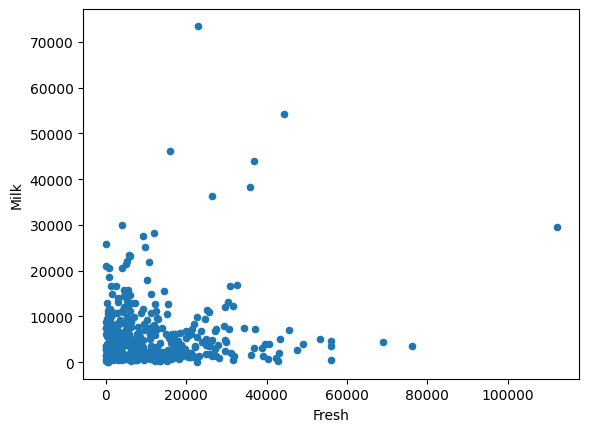

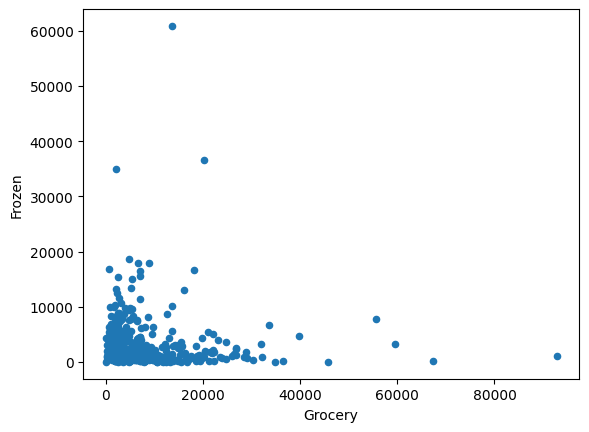

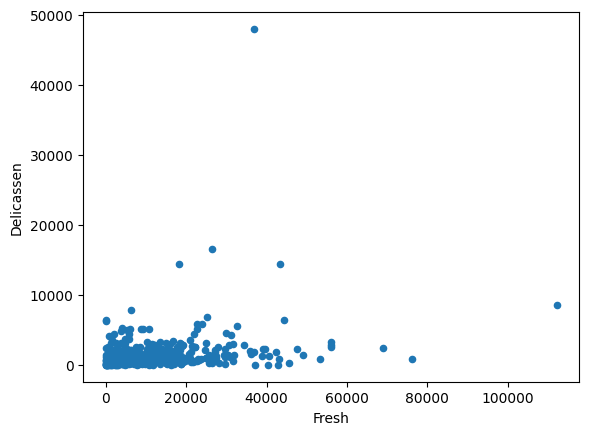

In [6]:
customers.plot.scatter(x="Fresh", y="Milk")
customers.plot.scatter(x="Grocery", y="Frozen")
customers.plot.scatter(x="Fresh", y="Delicassen")

In [7]:
def remove_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - 3*IQR) & (df_clean[col] <= Q3 + 3*IQR)]
    return df_clean

customers_clean = remove_outliers(customers, customers.columns)
customers_clean

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
...,...,...,...,...,...,...,...,...
434,1,3,16731,3922,7994,688,2371,838
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


<Axes: xlabel='Fresh', ylabel='Delicassen'>

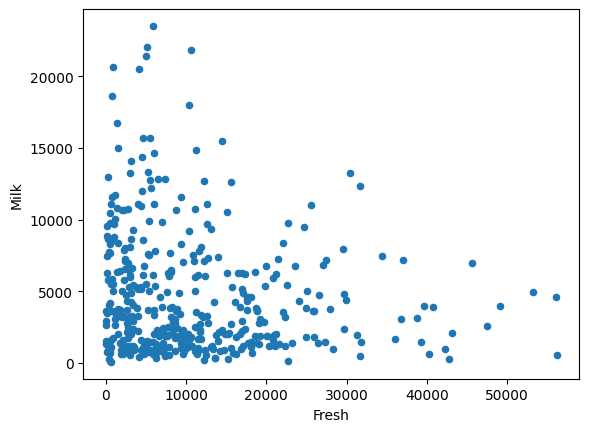

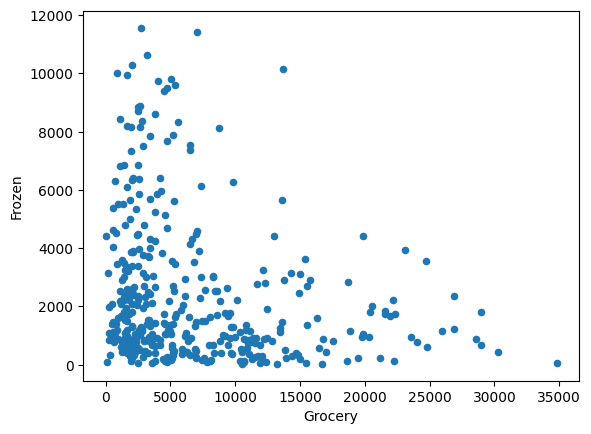

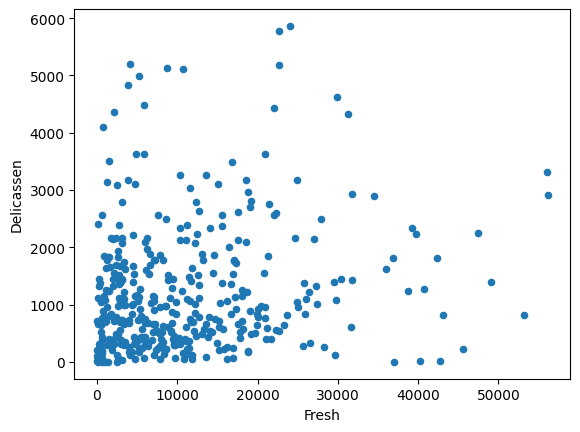

In [8]:
customers_clean.plot.scatter(x="Fresh", y="Milk")
customers_clean.plot.scatter(x="Grocery", y="Frozen")
customers_clean.plot.scatter(x="Fresh", y="Delicassen")

In [9]:
model_kmeans = KMeans(n_clusters=3,random_state=2, init="k-means++", max_iter=100)
model_kmeans.fit(customers_clean)


customers_clean['cluster'] = model_kmeans.labels_
customers_clean.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,2
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,1
5,2,3,9413,8259,5126,666,1795,1451,0


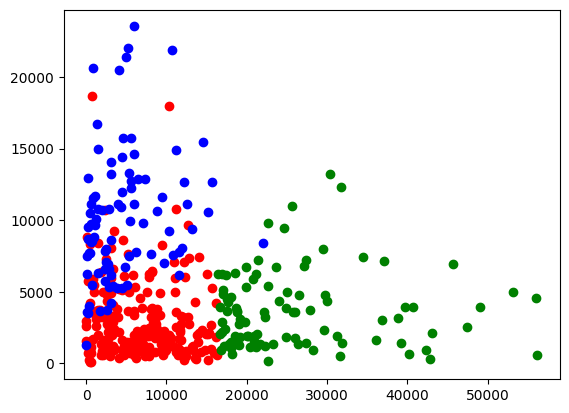

In [10]:
colors = ["red","green","blue","yellow"]
clusters = {i: [] for i in range(3)}

for i, row in customers_clean.iterrows():
    clusters[row["cluster"]].append(row)

clusters
for i in clusters:
    for series in clusters[i]:
        plt.scatter(x=series.iloc[2], y=series.iloc[3], color=colors[i])

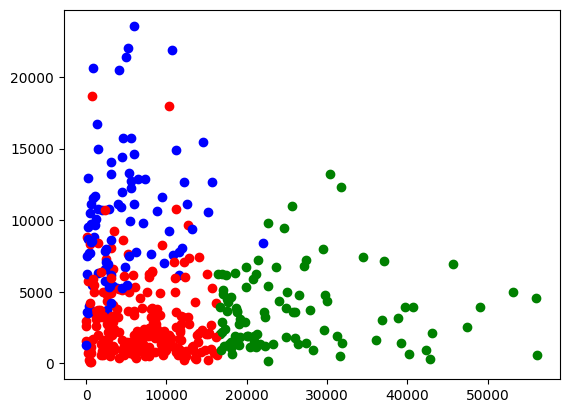

In [11]:

for i in customers_clean.index:
    plt.scatter(x=customers_clean.loc[i,"Fresh"], y=customers_clean.loc[i,"Milk"], color=colors[customers_clean["cluster"][i]])
    

In [12]:
print(model_kmeans.cluster_centers_)
model_kmeans.inertia_

[[1.12442396e+00 2.51612903e+00 6.89281567e+03 2.98024424e+03
  3.52491244e+03 2.19976959e+03 9.56336406e+02 9.32912442e+02]
 [1.21649485e+00 2.58762887e+00 2.59502165e+04 3.69945361e+03
  4.94285567e+03 3.56807216e+03 1.11852577e+03 1.55336082e+03]
 [1.86363636e+00 2.56818182e+00 4.75100000e+03 1.01130909e+04
  1.62527159e+04 1.39788636e+03 6.85195455e+03 1.44160227e+03]]


28863967398.4815

In [13]:
models = []
stds = []

for n in range(1,16):
    model_kmeans1 = KMeans(n_clusters=n, max_iter=100, random_state=1, init="k-means++")
    model_kmeans1.fit(customers_clean)
    models.append(model_kmeans1)
    stds.append(model_kmeans1.inertia_)

stds

[74086840496.56717,
 44435638153.69202,
 28863967398.4815,
 21487759565.850548,
 18801270060.271996,
 15509620538.917982,
 14073652751.56504,
 13122024768.636341,
 12570473930.256031,
 11704159882.142319,
 10925825666.44903,
 10500626360.202198,
 10002312453.257055,
 9440685776.3764,
 9070803358.444479]

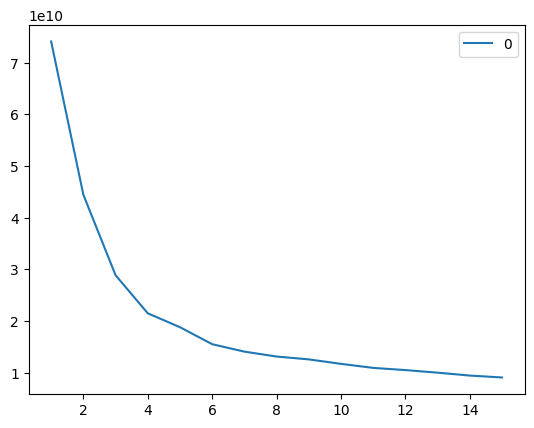

In [14]:
pd.DataFrame(stds, index=range(1,16)).plot()
plt.show()

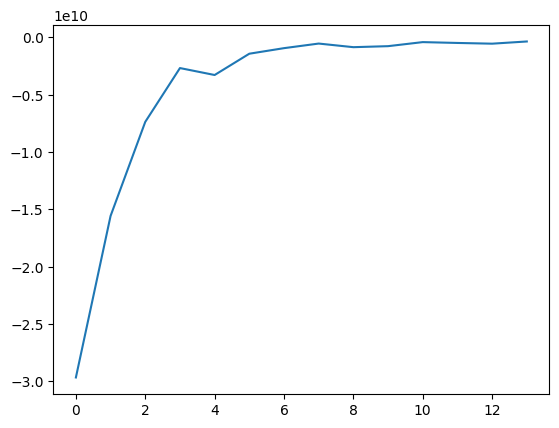

In [15]:
diff = np.diff(stds)

plt.plot(diff)
plt.show()

In [16]:
print(diff[1:])
print(diff[:-1])
diff

[-1.55716708e+10 -7.37620783e+09 -2.68648951e+09 -3.29164952e+09
 -1.43596779e+09 -9.51627983e+08 -5.51550838e+08 -8.66314048e+08
 -7.78334216e+08 -4.25199306e+08 -4.98313907e+08 -5.61626677e+08
 -3.69882418e+08]
[-2.96512023e+10 -1.55716708e+10 -7.37620783e+09 -2.68648951e+09
 -3.29164952e+09 -1.43596779e+09 -9.51627983e+08 -5.51550838e+08
 -8.66314048e+08 -7.78334216e+08 -4.25199306e+08 -4.98313907e+08
 -5.61626677e+08]


array([-2.96512023e+10, -1.55716708e+10, -7.37620783e+09, -2.68648951e+09,
       -3.29164952e+09, -1.43596779e+09, -9.51627983e+08, -5.51550838e+08,
       -8.66314048e+08, -7.78334216e+08, -4.25199306e+08, -4.98313907e+08,
       -5.61626677e+08, -3.69882418e+08])

In [17]:
diff_r = diff[1:]/diff[:-1]
diff_r

array([0.52516153, 0.47369405, 0.36421012, 1.22526052, 0.43624565,
       0.66270845, 0.57958661, 1.57068757, 0.89844349, 0.54629399,
       1.17195372, 1.12705399, 0.65859125])

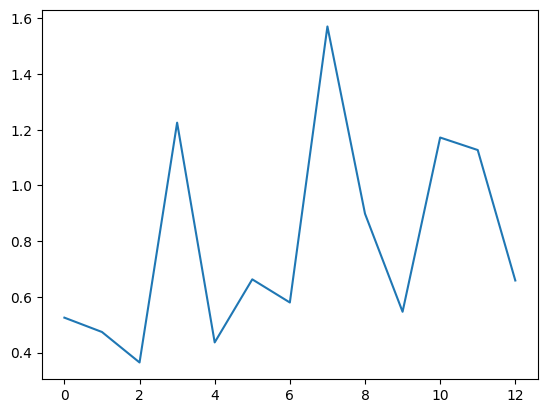

In [18]:
plt.plot(diff_r)

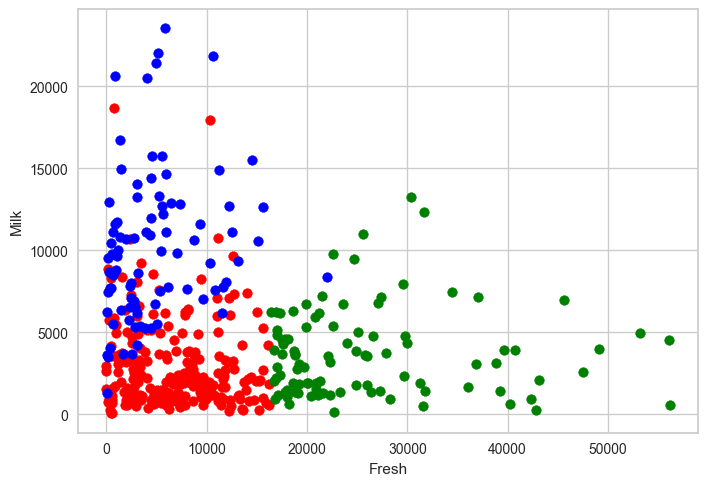

In [27]:
k = 3

model_kmeans = KMeans(n_clusters=k, max_iter=100, random_state=1, init="k-means++")
model_kmeans.fit(customers_clean)

customers_clean['cluster'] = model_kmeans.labels_

colors = ["red","green","blue","yellow","purple","orange","black","lightblue","pink"]
clusters = {i: [] for i in range(k)}


for i, row in customers_clean.iterrows():
    clusters[row["cluster"]].append(row)

for i in clusters:
    for series in clusters[i]:
        plt.scatter(x=series.iloc[2], y=series.iloc[3], color=colors[i])

plt.xlabel("Fresh")
plt.ylabel("Milk")
plt.show()
    

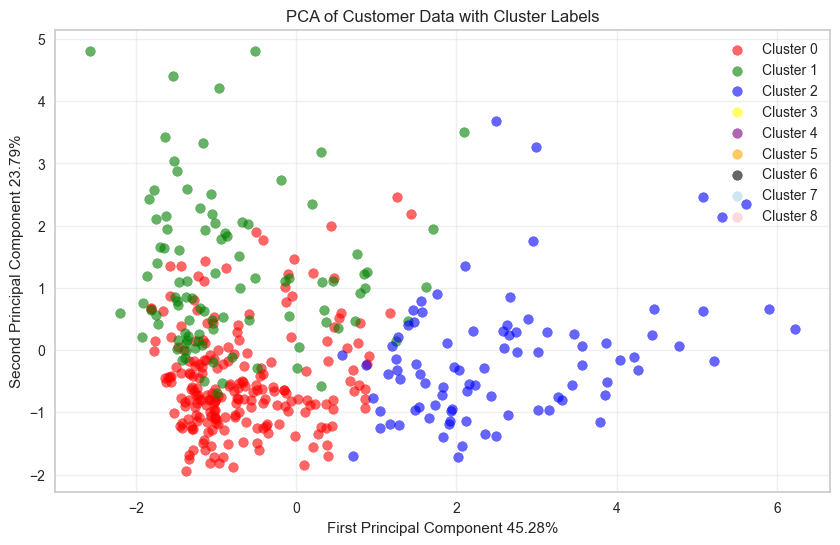

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# First standardize the features since PCA is sensitive to scale
scaler = StandardScaler()
# Exclude cluster column and any non-numeric columns
features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X_scaled = scaler.fit_transform(customers_clean[features])

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create visualization
plt.figure(figsize=(10, 6))

# Scatter plot with first two principal components
for cluster_id in range(len(colors)):
    mask = customers_clean['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

# Add labels and title
plt.xlabel(f'First Principal Component {pca.explained_variance_ratio_[0]*100:.2f}%')
plt.ylabel(f'Second Principal Component {pca.explained_variance_ratio_[1]*100:.2f}%')
plt.title('PCA of Customer Data with Cluster Labels')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [29]:
X_pca

array([[ 0.90356295, -0.09265386, -0.69415805,  0.07304968,  0.90678573,
        -0.18277435],
       [ 1.26753353,  0.21293263,  0.01453316,  0.45586442,  0.59144287,
        -0.05593648],
       [-1.23176161,  1.18863378,  0.94642301,  0.2212355 , -0.56570895,
         0.21106528],
       ...,
       [ 5.89621517,  0.66590619, -0.42927925, -1.52520983, -0.80381278,
        -0.25083225],
       [-0.85537854,  0.04524756, -0.7192444 ,  1.05495523, -0.16888848,
        -0.00955652],
       [-0.90908018, -1.71518722, -0.16803099,  0.19043376,  0.13194845,
         0.0493416 ]], shape=(402, 6))

In [30]:
pca.explained_variance_

array([2.72340186, 1.43124381, 0.72776226, 0.69337625, 0.32879302,
       0.1103854 ])

In [31]:
pca.components_[0]

array([-0.1954107 ,  0.51623709,  0.56976643, -0.18955545,  0.55366112,
        0.16795311])

Explained variance ratio:
PC1: 0.453
PC2: 0.238
Total: 0.691


<Figure size 1000x600 with 0 Axes>

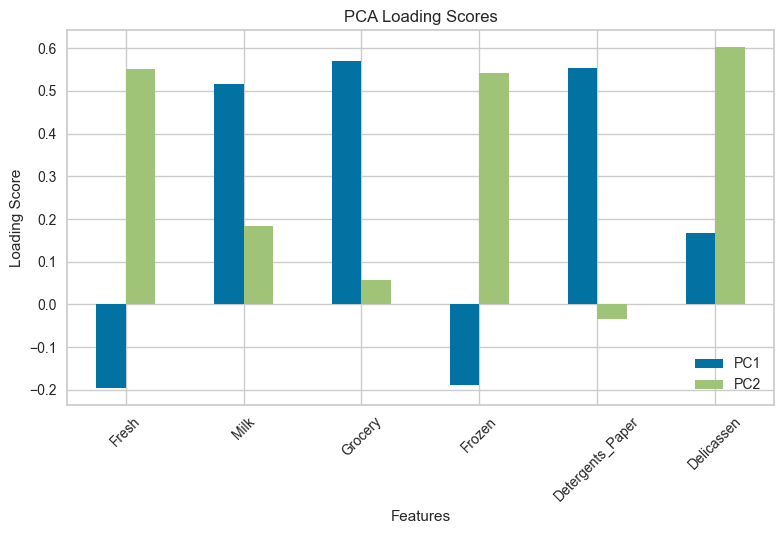

In [32]:

# Print explained variance ratio
print("Explained variance ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total: {sum(pca.explained_variance_ratio_[:2]):.3f}")

# Create a loading plot
plt.figure(figsize=(10, 6))
loading_scores = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'],
    index=features
)
loading_scores[['PC1', 'PC2']].plot(kind='bar')
plt.title('PCA Loading Scores')
plt.xlabel('Features')
plt.ylabel('Loading Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

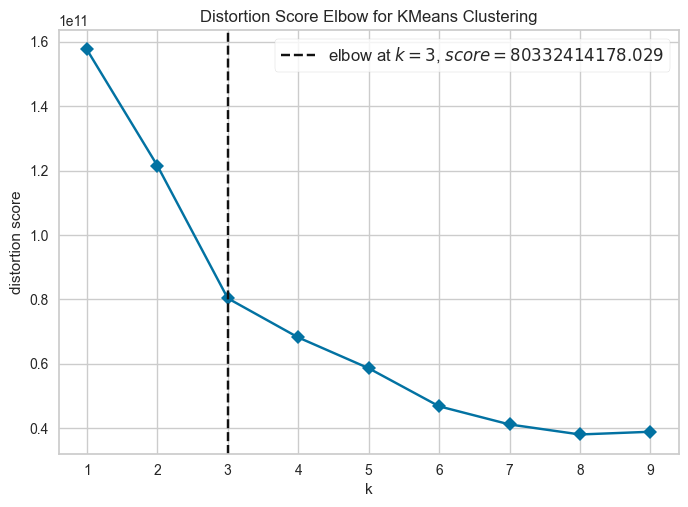

,estimator,KMeans(max_it...andom_state=1)
,ax,<Axes: title=...ortion score'>
,k,"(1, ...)"
,metric,'distortion'
,distance_metric,'euclidean'
,timings,False
,locate_elbow,True
,n_clusters,9
,init,'k-means++'
,n_init,'auto'
,max_iter,100


In [33]:
import sys, setuptools._distutils
sys.modules["distutils"] = setuptools._distutils

from yellowbrick.cluster.elbow import kelbow_visualizer


kelbow_visualizer(model_kmeans,X=customers ,k=(1,10), timings=False)

In [58]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

syms = ["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"] 
df = customers_clean[syms].transpose()
Z = linkage(df, metric="euclidean", method="average")
Z

array([[3.00000000e+00, 5.00000000e+00, 5.55464794e+04, 2.00000000e+00],
       [4.00000000e+00, 6.00000000e+00, 7.61458286e+04, 3.00000000e+00],
       [1.00000000e+00, 2.00000000e+00, 9.41150612e+04, 2.00000000e+00],
       [7.00000000e+00, 8.00000000e+00, 1.25975919e+05, 5.00000000e+00],
       [0.00000000e+00, 9.00000000e+00, 2.77947085e+05, 6.00000000e+00]])

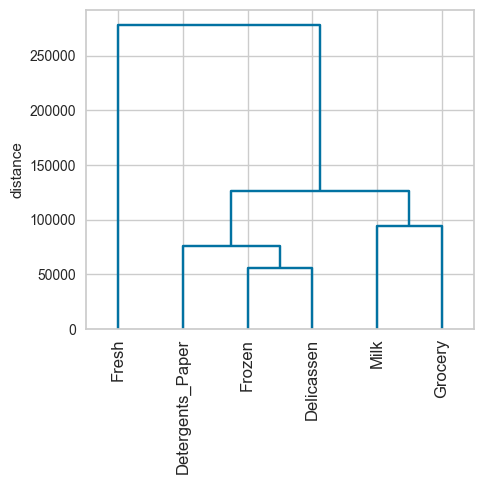

In [59]:
fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(df.index), color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel('distance')

plt.tight_layout()
plt.show()

dict_items([('ee', 'nurek')])

Add a new contact(add)
View all contacts(view)
Search a contact(search) 
Delete a contact(delete)
Exit(exit)
good bye
